In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# fetch dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)

# data (as pandas dataframes)
X = parkinsons_telemonitoring.data.features
y = parkinsons_telemonitoring.data.targets

# metadata
print(parkinsons_telemonitoring.metadata)

# variable information
print(parkinsons_telemonitoring.variables)


{'uci_id': 189, 'name': 'Parkinsons Telemonitoring', 'repository_url': 'https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring', 'data_url': 'https://archive.ics.uci.edu/static/public/189/data.csv', 'abstract': "Oxford Parkinson's Disease Telemonitoring Dataset", 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 5875, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['motor_UPDRS', 'total_UPDRS'], 'index_col': ['subject#'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5ZS3N', 'creators': ['Athanasios Tsanas', 'Max Little'], 'intro_paper': {'ID': 229, 'type': 'NATIVE', 'title': "Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests", 'authors': 'A. Tsanas, Max A. Little, P. McSharry, L. Ramig', 'venue': 'IEEE Transactions on Bio

In [ ]:
print(X.head())
print(y.head())

   age  test_time  Jitter(%)  Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  \
0   72     5.6431    0.00662     0.000034     0.00401      0.00317   
1   72    12.6660    0.00300     0.000017     0.00132      0.00150   
2   72    19.6810    0.00481     0.000025     0.00205      0.00208   
3   72    25.6470    0.00528     0.000027     0.00191      0.00264   
4   72    33.6420    0.00335     0.000020     0.00093      0.00130   

   Jitter:DDP  Shimmer  Shimmer(dB)  Shimmer:APQ3  Shimmer:APQ5  \
0     0.01204  0.02565        0.230       0.01438       0.01309   
1     0.00395  0.02024        0.179       0.00994       0.01072   
2     0.00616  0.01675        0.181       0.00734       0.00844   
3     0.00573  0.02309        0.327       0.01106       0.01265   
4     0.00278  0.01703        0.176       0.00679       0.00929   

   Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE      DFA      PPE  \
0        0.01662      0.04314  0.014290  21.640  0.41888  0.54842  0.16006   
1        0.01689    

In [ ]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (5875, 19)
Dimensiones de y: (5875, 2)


Entrenamiento


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

#Regresion lineal

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

Datos de entrenamiento: (4700, 19)
Datos de prueba: (1175, 19)


In [ ]:

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

scoring = {
    "RMSE": make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    ),
    "R2": "r2"
}

cv_results = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

rmse_scores = -cv_results["test_RMSE"]
r2_scores = cv_results["test_R2"]

print("RMSE por fold:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())
print("RMSE desviación estándar:", rmse_scores.std())

print("\nR² por fold:", r2_scores)
print("R² promedio:", r2_scores.mean())
print("R² desviación estándar:", r2_scores.std())

RMSE por fold: [8.36179948 8.81087559 8.90410018 8.7930894  8.6363142 ]
RMSE promedio: 8.70123576988505
RMSE desviación estándar: 0.19028597098720684

R² por fold: [0.21091785 0.14276394 0.14919714 0.15402949 0.16994649]
R² promedio: 0.16537098297975597
R² desviación estándar: 0.02448164203382825


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select="auto",  # deja que decida con base en el score
    direction="forward",
    scoring="r2",
    cv=5
)

sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()].tolist()
print("Número de variables seleccionadas:", len(selected_features))
print("Variables seleccionadas:", selected_features)
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

linear_model_sel = LinearRegression()
cv_results_sel = cross_validate(
    linear_model_sel, X_train_sel, y_train, cv=5, scoring=scoring
)

print("RMSE promedio (con selección):", (-cv_results_sel["test_RMSE"]).mean())
print("R² promedio (con selección):", cv_results_sel["test_R2"].mean())

Número de variables seleccionadas: 9
Variables seleccionadas: ['age', 'test_time', 'Jitter(Abs)', 'Jitter:DDP', 'Shimmer:APQ3', 'HNR', 'DFA', 'PPE', 'sex']
RMSE promedio (con selección): 8.718479754846976
R² promedio (con selección): 0.1618245297560857


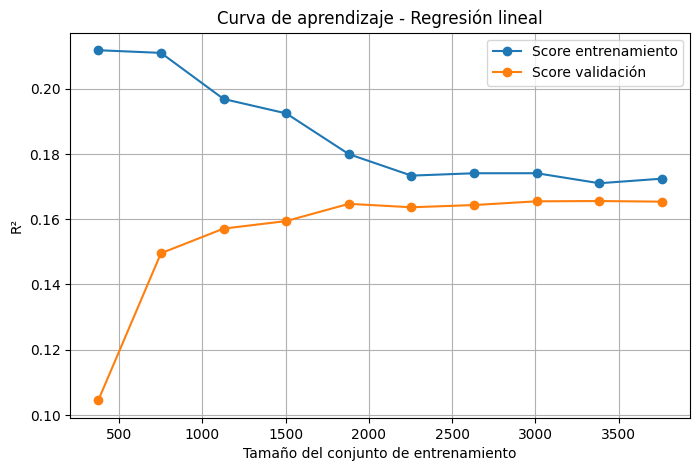

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.dummy import DummyRegressor
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_train, y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, "o-", label="Score entrenamiento")
plt.plot(train_sizes, test_mean, "o-", label="Score validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R²")
plt.title("Curva de aprendizaje - Regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
dummy = DummyRegressor(strategy="mean")
dummy_scores = cross_validate(dummy, X_train, y_train, cv=5, scoring="r2")
print("R² promedio del baseline (Dummy):", dummy_scores["test_score"].mean())

R² promedio del baseline (Dummy): -0.0004714892124663139


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# KNN es sensible a la escala, así que conviene usar un pipeline con StandardScaler
knn_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))

cv_results_knn = cross_validate(knn_model, X_train, y_train, cv=5, scoring=scoring)

print("RMSE promedio (KNN):", (-cv_results_knn["test_RMSE"]).mean())
print("R² promedio (KNN):", cv_results_knn["test_R2"].mean())

RMSE promedio (KNN): 5.703761342434442
R² promedio (KNN): 0.6455518078710376


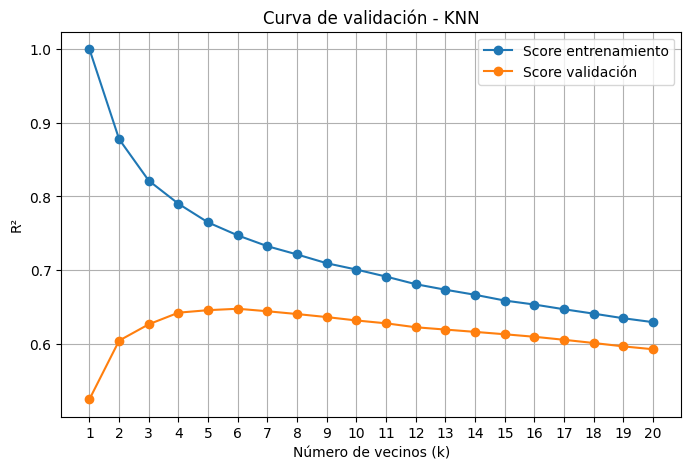

Mejor valor de k: 6
Mejor R² promedio: 0.6474649368179964


In [ ]:
from sklearn.model_selection import validation_curve

k_range = range(1, 21)

train_scores_knn, test_scores_knn = validation_curve(
    make_pipeline(StandardScaler(), KNeighborsRegressor()),
    X_train, y_train,
    param_name="kneighborsregressor__n_neighbors",
    param_range=k_range,
    cv=5,
    scoring="r2"
)

test_mean_knn = test_scores_knn.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(k_range, train_scores_knn.mean(axis=1), "o-", label="Score entrenamiento")
plt.plot(k_range, test_mean_knn, "o-", label="Score validación")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("R²")
plt.title("Curva de validación - KNN")
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(test_mean_knn)]
print("Mejor valor de k:", best_k)
print("Mejor R² promedio:", test_mean_knn.max())

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

cv_results_rf = cross_validate(rf_model, X_train, y_train, cv=5, scoring=scoring)

print("RMSE promedio (Random Forest):", (-cv_results_rf["test_RMSE"]).mean())
print("R² promedio (Random Forest):", cv_results_rf["test_R2"].mean())

RMSE promedio (Random Forest): 1.6862090781375993
R² promedio (Random Forest): 0.9686239481141425


age              0.664229
DFA              0.091617
sex              0.079053
test_time        0.073169
Jitter(Abs)      0.017080
HNR              0.014129
RPDE             0.013046
PPE              0.008100
NHR              0.005001
Shimmer:APQ11    0.004663
Shimmer(dB)      0.004456
Shimmer:DDA      0.004135
Shimmer:APQ5     0.004120
Shimmer:APQ3     0.003720
Shimmer          0.003635
Jitter:DDP       0.002641
Jitter:RAP       0.002432
Jitter:PPQ5      0.002412
Jitter(%)        0.002362
dtype: float64


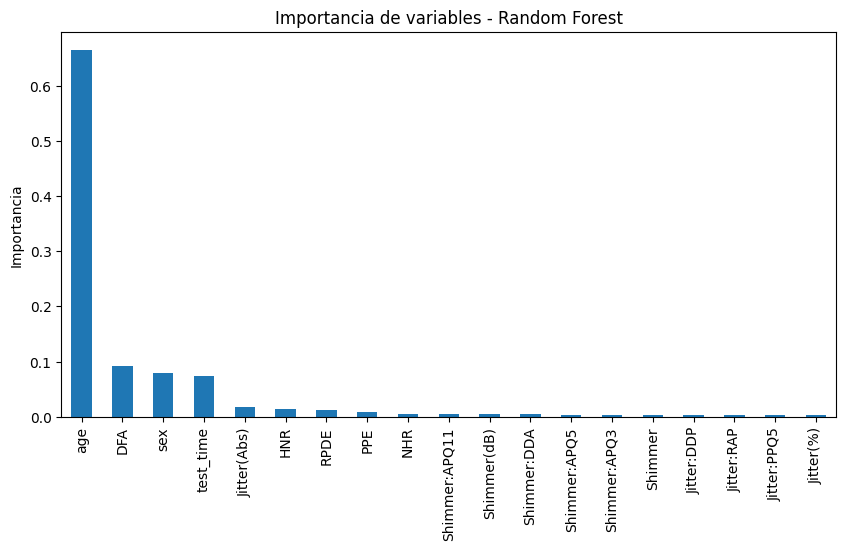

In [ ]:

rf_model.fit(X_train, y_train)

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances)

importances.plot(kind="bar", figsize=(10,5))
plt.title("Importancia de variables - Random Forest")
plt.ylabel("Importancia")
plt.show()

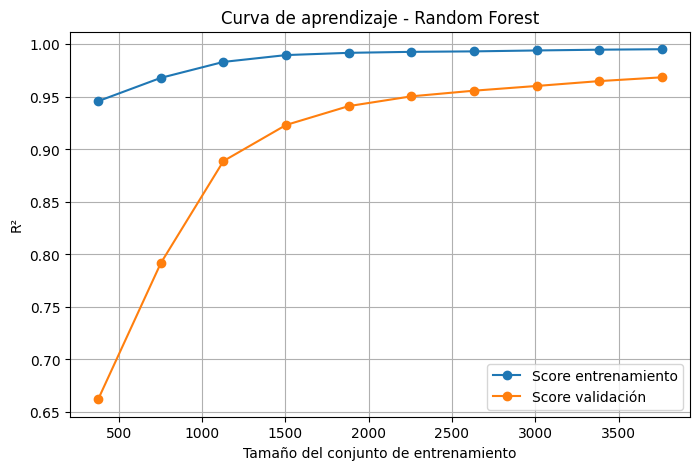

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes_rf, train_scores_rf, validation_scores_rf = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean_rf = train_scores_rf.mean(axis=1)
validation_mean_rf = validation_scores_rf.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes_rf,
    train_mean_rf,
    "o-",
    label="Score entrenamiento"
)

plt.plot(
    train_sizes_rf,
    validation_mean_rf,
    "o-",
    label="Score validación"
)

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R²")
plt.title("Curva de aprendizaje - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Resultados de los modelos

resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "KNN (k=6)",
        "Random Forest"
    ],
    "RMSE": [
        (-cv_results["test_RMSE"]).mean(),
        (-cv_results_knn["test_RMSE"]).mean(),
        (-cv_results_rf["test_RMSE"]).mean()
    ],
    "R²": [
        cv_results["test_R2"].mean(),
        cv_results_knn["test_R2"].mean(),
        cv_results_rf["test_R2"].mean()
    ]
})

display(resultados)

,Modelo,RMSE,R²
0,Regresión Lineal,8.701236,0.165371
1,KNN (k=6),5.703761,0.645552
2,Random Forest,1.686209,0.968624


In [ ]:
knn_best = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=6)
)

cv_results_knn_best = cross_validate(
    knn_best,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

knn_best_rmse = (-cv_results_knn_best["test_RMSE"]).mean()
knn_best_r2 = cv_results_knn_best["test_R2"].mean()

print("KNN con k=6")
print("RMSE promedio:", knn_best_rmse)
print("R² promedio:", knn_best_r2)

KNN con k=6
RMSE promedio: 5.687320403534642
R² promedio: 0.6474649368179964


In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "KNN (k=6)",
        "Random Forest"
    ],
    "RMSE": [
        (-cv_results["test_RMSE"]).mean(),
        knn_best_rmse,
        (-cv_results_rf["test_RMSE"]).mean()
    ],
    "R²": [
        cv_results["test_R2"].mean(),
        knn_best_r2,
        cv_results_rf["test_R2"].mean()
    ]
})

display(resultados)

,Modelo,RMSE,R²
0,Regresión Lineal,8.701236,0.165371
1,KNN (k=6),5.687320,0.647465
2,Random Forest,1.686209,0.968624
